# Classification

- Author: Tulsi Marshall
- Date: 2026-07
- Dataset: UCI Student Performance, student-mat.csv (Cortez, P. 2014, UCI Machine Learning Repository, https://doi.org/10.24432/C5TG7T, CC BY 4.0)
- Target: pass/fail, derived from G3
  
Select Kernel before running.
Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This project uses the UCI Student Performance dataset. The data covers 395 students in a secondary school mathematics course at two Portuguese schools, with 33 columns describing demographics, family background, social life, school support, and grades. It was collected from school reports and questionnaires by Cortez and Silva (2008).

I started from a question in my own work as a learning center coordinator: can we tell which students are at risk while there is still time to help? To be exact about the data, G1, G2, and G3 are three grading periods of one math course across a single school year, not three separate classes. The target is pass or fail on G3, the final grade, with 10 or above counting as a pass. Because I have chosen a target and that target is a category, this is a supervised classification problem.

What shaped the whole project is that the moment you make a prediction decides how much of the grade record exists yet. So I built three prediction points, one per grading period, labeled fall, winter, and spring, and ran the same model at each to see how the prediction changes as more of the record becomes available.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M03-STUDENTS", level="DEBUG")
log_header(LOG, "M03")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-19 08:08:26 | INFO | M03-STUDENTS | === RUN START ===
2026-07-19 08:08:26 | INFO | M03-STUDENTS | project=M03
2026-07-19 08:08:26 | INFO | M03-STUDENTS | repo_dir=ml-03-classification
2026-07-19 08:08:26 | INFO | M03-STUDENTS | python=3.14.2
2026-07-19 08:08:26 | INFO | M03-STUDENTS | os=Windows 11
2026-07-19 08:08:26 | INFO | M03-STUDENTS | shell=powershell
2026-07-19 08:08:26 | INFO | M03-STUDENTS | cwd=notebooks
2026-07-19 08:08:26 | INFO | M03-STUDENTS | github_actions=False
2026-07-19 08:08:26 | INFO | M03-STUDENTS | Confirming installation:
2026-07-19 08:08:26 | INFO | M03-STUDENTS |   python:       3.14.2
2026-07-19 08:08:26 | INFO | M03-STUDENTS |   pandas:       3.0.3
2026-07-19 08:08:26 | INFO | M03-STUDENTS |   numpy:        2.5.1
2026-07-19 08:08:26 | INFO | M03-STUDENTS |   scikit-learn: 1.9.0
2026-07-19 08:08:26 | INFO | M03-STUDENTS |   seaborn:      0.13.2
2026-07-19 08:08:26 | INFO | M03-STUDENTS |   matplotlib:   3.11.0


## Section 2. Load and Assess the Data

2026-07-19 08:15:00 | INFO | M03-STUDENTS | Loading dataset: student-mat
2026-07-19 08:15:00 | INFO | M03-STUDENTS | Loaded: 395 rows (instances), 33 columns
2026-07-19 08:15:00 | INFO | M03-STUDENTS | Per-column completeness and type:
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   school       str      present=100.0%  missing=0
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   sex          str      present=100.0%  missing=0
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   age          int64    present=100.0%  missing=0
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   address      str      present=100.0%  missing=0
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   famsize      str      present=100.0%  missing=0
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   Pstatus      str      present=100.0%  missing=0
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   Medu         int64    present=100.0%  missing=0
2026-07-19 08:15:00 | INFO | M03-STUDENTS |   Fedu         int64    present=100.0%  missing=0
2026-07-19 0

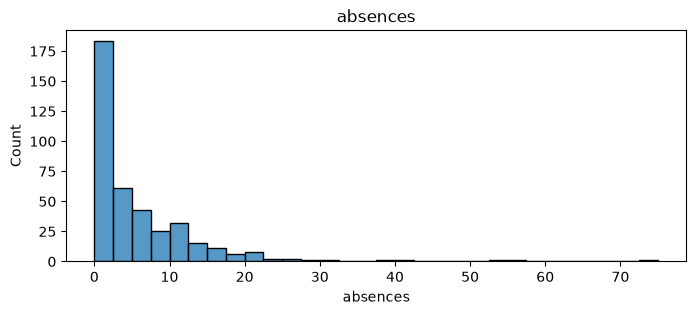

2026-07-19 08:15:00 | INFO | M03-STUDENTS | absences: max=75, median=4.0
2026-07-19 08:15:00 | INFO | M03-STUDENTS | absences over 20: 15 students
2026-07-19 08:15:00 | INFO | M03-STUDENTS | Original rows: 395
2026-07-19 08:15:00 | INFO | M03-STUDENTS | Model rows:    395
2026-07-19 08:15:00 | INFO | M03-STUDENTS | Classes in target 'result': ['fail', 'pass']
2026-07-19 08:15:00 | DEBUG | M03-STUDENTS | Class counts:
result
pass    265
fail    130
Name: count, dtype: int64


In [3]:
# === Section 2. Load and Assess the Data ===

# CUSTOM: This dataset is a CSV file in data/raw, downloaded from the UCI
# Machine Learning Repository. The file is semicolon-separated, so we tell
# pandas to use ";" as the separator rather than the default comma.
# Notebooks run from notebooks/, so "../" steps up to the project root.

DATASET_NAME: Final[str] = "student-mat"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv(f"../data/raw/{DATASET_NAME}.csv", sep=";")
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# --- Assess the raw data before deciding anything ---

# Report the facts first: how complete each column is, its type, and the spread
# of the columns we plan to use. The code reports; the analyst decides. The data
# is already complete, so this confirms that before we build the target.

LOG.info("Per-column completeness and type:")
n_rows: int = df.shape[0]
for col in df.columns:
    missing: int = int(df[col].isna().sum())
    pct_present: float = 100.0 * (n_rows - missing) / n_rows
    LOG.info(
        f"  {str(col):12s} {str(df[col].dtype):8s} present={pct_present:5.1f}%  missing={missing}"
    )

# Numeric summary of the columns any quarter will use (raw, before the target).
FEATURE_POOL: Final[list[str]] = [
    "Medu",
    "Fedu",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
]
LOG.info("Numeric summary of the candidate feature columns (spread and outliers):")
LOG.debug(f"\n{df[FEATURE_POOL].describe()}")

# Look at absences, the one feature with a heavy tail.
plt.figure(figsize=(8, 3))
sns.histplot(df["absences"], bins=30)
plt.title("absences")
plt.savefig("../docs/images/absences_gracecode42.png", dpi=150, bbox_inches="tight")
plt.show()

LOG.info(f"absences: max={df['absences'].max()}, median={df['absences'].median()}")
LOG.info(f"absences over 20: {(df['absences'] > 20).sum()} students")

# --- Build the target and the feature cases from what we just saw ---

# CUSTOM: Build the target. G3 is the final grade on the Portuguese 0-20 scale,
# where 10 is the pass mark. We turn it into a two-class label, pass or fail.
PASS_MARK: Final[int] = 10
df["result"] = np.where(df["G3"] >= PASS_MARK, "pass", "fail")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "result"

# CUSTOM: A small, defensible feature set. Parent education, study time, past
# failures, and attendance are durable indicators of how a student is doing,
# and a smaller model reasons and defends better than using every column.
FEATURES_BASE: Final[list[str]] = ["Medu", "Fedu", "studytime", "failures", "absences"]

# CUSTOM: Three prediction points, one per quarter. The model is the same each
# time; what changes is which period grades exist when the alert would be sent.
# G3 is never a feature, since it is the basis of the target.
FEATURES_FALL: Final[list[str]] = FEATURES_BASE  # no grades yet
FEATURES_WINTER: Final[list[str]] = FEATURES_BASE + ["G1"]  # first period grade in
FEATURES_SPRING: Final[list[str]] = FEATURES_BASE + ["G1", "G2"]  # first and second in

# Point required at the widest case so every column any quarter uses is present.
required: list[str] = [TARGET_COL, *FEATURES_SPRING]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

The data is complete, so nothing here needs cleaning. The numeric summary confirms the feature columns are on their own small scales, mostly survey ranks from 0 to 4 or 1 to 5, with failures and absences as true counts.

The one column with a heavy tail is absences. Most students miss only a few days, but a handful reach the thirties and one reaches 75. I left it raw. A decision tree splits on order rather than distance, so an extreme value falls on one side of a cut without pulling it the way it would pull a mean. That is a reason the tree is a reasonable first model here. Scaling or capping would matter for a distance-based model like the SVC I add later, which is a question for that section.

## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.


In [4]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Split into stratified train and test sets, once per quarter.

WHY: Scoring on held-out data is the only honest estimate of performance on new
data. Stratifying preserves the class balance in both splits. We split each
feature case off the same rows and the same random state, so the only thing that
differs across quarters is which grades are available, not the students.
"""
y: pd.Series = df_model[TARGET_COL]

X_fall: pd.DataFrame = df_model[FEATURES_FALL]
X_winter: pd.DataFrame = df_model[FEATURES_WINTER]
X_spring: pd.DataFrame = df_model[FEATURES_SPRING]

X_train_fall, X_test_fall, y_train, y_test = train_test_split(
    X_fall, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_winter, X_test_winter, _, _ = train_test_split(
    X_winter, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_spring, X_test_spring, _, _ = train_test_split(
    X_spring, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

LOG.info(f"Train instances: {len(X_train_fall)}")
LOG.info(f"Test instances:  {len(X_test_fall)}")

2026-07-19 08:26:44 | INFO | M03-STUDENTS | Train instances: 316
2026-07-19 08:26:44 | INFO | M03-STUDENTS | Test instances:  79


## Section 4. Fit a Classifier


ANALYST CHOICE

The model and its parameters are yours to choose. 

This project uses a decision tree with max_depth = MAX_DEPTH. 

Section 6 shows how that choice moves performance; 
here we fit one model per quarter and read its scores.


In [5]:
# === Section 4. Fit a Classifier ===

"""Fit a decision-tree classifier on the training data.

WHY: create -> .fit() -> .predict()
is the same pattern for every scikit-learn estimator.
Learning it once carries to every later model.
"""

# MAX_DEPTH is one tunable parameter of the model.
# For a decision tree, max_depth controls complexity:
#   - shallow underfits
#   - deep overfits
# Section 6 shows the effect; we must choose and defend a value.
# We use the same depth for all three quarters so the only thing that
# changes across them is which grades the model can see.
MAX_DEPTH: Final[int] = 3

LOG.info(f"Fitting one DecisionTreeClassifier(max_depth={MAX_DEPTH}) per quarter")

tree_fall = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
tree_fall.fit(X_train_fall, y_train)

tree_winter = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
tree_winter.fit(X_train_winter, y_train)

tree_spring = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
tree_spring.fit(X_train_spring, y_train)

LOG.info("Fit three trees: fall (no grades), winter (+G1), spring (+G1, G2)")

2026-07-19 08:28:09 | INFO | M03-STUDENTS | Fitting one DecisionTreeClassifier(max_depth=3) per quarter
2026-07-19 08:28:09 | INFO | M03-STUDENTS | Fit three trees: fall (no grades), winter (+G1), spring (+G1, G2)


## Section 5. Evaluate the Model

2026-07-19 10:20:11 | INFO | M03-STUDENTS | --- Fall --- accuracy = 0.658
2026-07-19 10:20:11 | INFO | M03-STUDENTS | Per-class precision / recall / F1:
2026-07-19 10:20:11 | DEBUG | M03-STUDENTS | 
              precision    recall  f1-score   support

        fail       0.44      0.15      0.23        26
        pass       0.69      0.91      0.78        53

    accuracy                           0.66        79
   macro avg       0.57      0.53      0.50        79
weighted avg       0.61      0.66      0.60        79



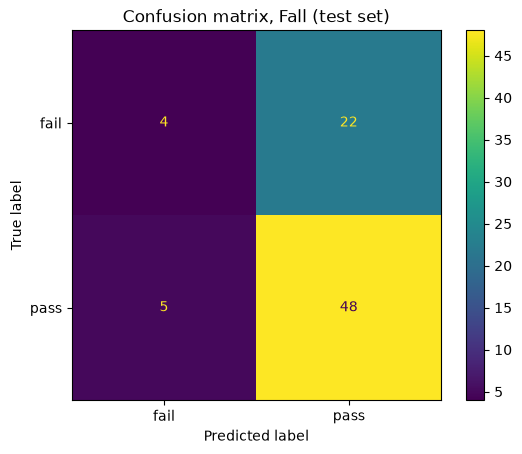

2026-07-19 10:20:12 | INFO | M03-STUDENTS | --- Winter --- accuracy = 0.835
2026-07-19 10:20:12 | INFO | M03-STUDENTS | Per-class precision / recall / F1:
2026-07-19 10:20:12 | DEBUG | M03-STUDENTS | 
              precision    recall  f1-score   support

        fail       0.78      0.69      0.73        26
        pass       0.86      0.91      0.88        53

    accuracy                           0.84        79
   macro avg       0.82      0.80      0.81        79
weighted avg       0.83      0.84      0.83        79



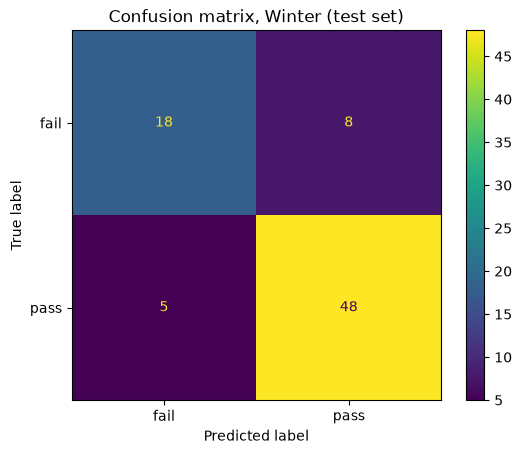

2026-07-19 10:20:12 | INFO | M03-STUDENTS | --- Spring --- accuracy = 0.873
2026-07-19 10:20:12 | INFO | M03-STUDENTS | Per-class precision / recall / F1:
2026-07-19 10:20:12 | DEBUG | M03-STUDENTS | 
              precision    recall  f1-score   support

        fail       0.74      0.96      0.83        26
        pass       0.98      0.83      0.90        53

    accuracy                           0.87        79
   macro avg       0.86      0.90      0.87        79
weighted avg       0.90      0.87      0.88        79



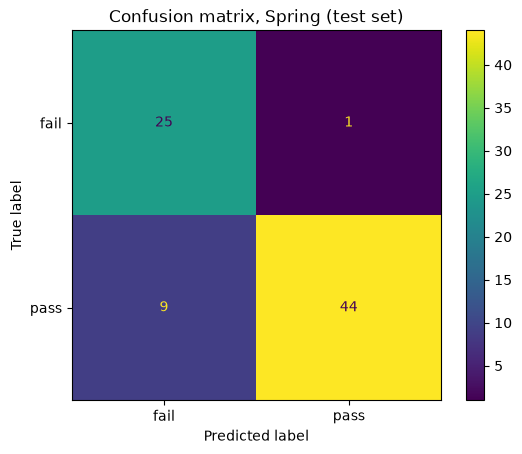

2026-07-19 10:20:12 | INFO | M03-STUDENTS | Summary across quarters (fail = the at-risk class an alert is for):
2026-07-19 10:20:12 | DEBUG | M03-STUDENTS | 
quarter  accuracy  fail_recall  fail_precision  fail_f1  pass_recall  pass_precision  pass_f1
   Fall     0.658         0.15            0.44     0.23         0.91            0.69     0.78
 Winter     0.835         0.69            0.78     0.73         0.91            0.86     0.88
 Spring     0.873         0.96            0.74     0.83         0.83            0.98     0.90


In [6]:
# === Section 5. Evaluate the Model ===

"""Score each quarter's tree on held-out data, per class, and compare.

WHY: A single accuracy number hides which class gets confused, and here it also
hides the point, which is how the scores change as more grades become available.
We print the full classification report and a confusion matrix for each quarter,
then collect the key numbers into one table so the quarters sit side by side.
"""


# --- The recipe, written once ---
def evaluate(name: str, model, X_test) -> dict:
    """Score one fitted tree on its test set: print the report, draw the
    confusion matrix, and return a row of numbers for the summary table."""
    y_pred = model.predict(X_test)

    acc = float(accuracy_score(y_test, y_pred))
    LOG.info(f"--- {name} --- accuracy = {acc:.3f}")
    LOG.info("Per-class precision / recall / F1:")
    LOG.debug(
        f"\n{classification_report(y_test, y_pred, labels=['fail', 'pass'], zero_division=0)}"
    )

    # Confusion matrix for this quarter (rows = actual, cols = predicted).
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, labels=["fail", "pass"]
    )
    plt.title(f"Confusion matrix, {name} (test set)")
    plt.savefig(
        f"../docs/images/confusion_{name.lower()}_gracecode42.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    # Pull the fail and pass scores into a flat row for the table.
    report = classification_report(
        y_test, y_pred, labels=["fail", "pass"], output_dict=True, zero_division=0
    )
    return {
        "quarter": name,
        "accuracy": round(acc, 3),
        "fail_recall": round(report["fail"]["recall"], 2),
        "fail_precision": round(report["fail"]["precision"], 2),
        "fail_f1": round(report["fail"]["f1-score"], 2),
        "pass_recall": round(report["pass"]["recall"], 2),
        "pass_precision": round(report["pass"]["precision"], 2),
        "pass_f1": round(report["pass"]["f1-score"], 2),
    }


# --- The three calls, one per quarter ---
results = [
    evaluate("Fall", tree_fall, X_test_fall),
    evaluate("Winter", tree_winter, X_test_winter),
    evaluate("Spring", tree_spring, X_test_spring),
]

# --- The comparison table, built from what the calls returned ---
summary = pd.DataFrame(results)
LOG.info("Summary across quarters (fail = the at-risk class an alert is for):")
LOG.debug(f"\n{summary.to_string(index=False)}")

## Section 6. Parameter Selection Affects Performance

We **sweep** `max_depth`.

We try every value in a range and plot 
accuracy on **train** vs **test** for each one.

Choose a range that starts low (1–2) and 
goes high enough to see the train score 
plateau near 1.0 
while the test score levels off or drops. 

How high that is depends on the dataset.
More features and more complex patterns 
need deeper trees to overfit. 
Start wide and narrow in.

The shape is the lesson:

- very shallow trees **underfit** (both scores low)
- very deep trees **overfit** (train near 1.0, test drops or flattens)

The best depth is where test accuracy is strong 
and the train/test gap is small. 

Finding that is the job of the analyst.

2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 1  train=0.820  test=0.797
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 2  train=0.820  test=0.785
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 3  train=0.858  test=0.835
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 4  train=0.883  test=0.772
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 5  train=0.896  test=0.823
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 6  train=0.911  test=0.810
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 7  train=0.927  test=0.861
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 8  train=0.949  test=0.835
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth= 9  train=0.965  test=0.848
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth=10  train=0.975  test=0.848
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth=11  train=0.981  test=0.835
2026-07-19 10:32:42 | DEBUG | M03-STUDENTS |   depth=12  train=0.981  test=0.835


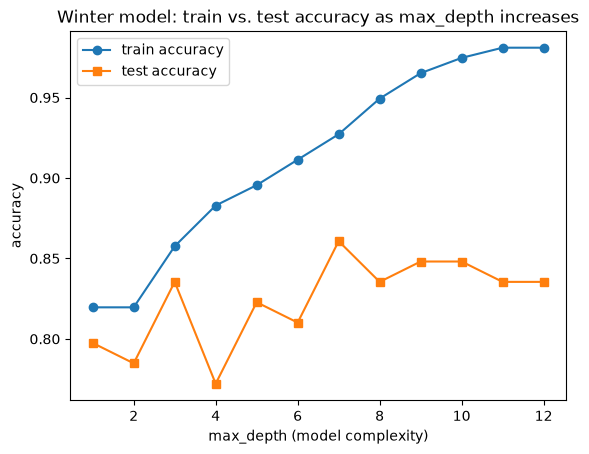

In [7]:
# === Section 6. How Parameter Selection Affects Performance ===

# CUSTOM: ANALYST CHOICE
# We sweep max_depth on the Winter model. Fall has too little signal to tune,
# and Spring is nearly trivial because G2 sits close to the final grade. Winter
# is the quarter where depth actually trades off and where an alert would be used.
MAX_SWEEP: Final[int] = 12

# Declare lists to hold the depths and corresponding train/test scores.
depths: list[int] = list(range(1, MAX_SWEEP + 1))
train_scores: list[float] = []
test_scores: list[float] = []

for depth in depths:
    # create and fit a DecisionTreeClassifier with the current depth and random_state
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train_winter, y_train)

    acc_score_train = accuracy_score(y_train, m.predict(X_train_winter))
    acc_score_test = accuracy_score(y_test, m.predict(X_test_winter))

    # Use float() to convert from numpy Float to native Python float.
    train_scores.append(float(acc_score_train))
    test_scores.append(float(acc_score_test))

    LOG.debug(
        f"  depth={depth:2d}  train={train_scores[-1]:.3f}  test={test_scores[-1]:.3f}"
    )

# start a new figure
plt.figure()

# plot the train and test scores against the depths
plt.plot(depths, train_scores, marker="o", label="train accuracy")
plt.plot(depths, test_scores, marker="s", label="test accuracy")

# label the axes and add a title and legend
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.title("Winter model: train vs. test accuracy as max_depth increases")
plt.savefig(
    "../docs/images/depth_sweep_winter_gracecode42.png", dpi=150, bbox_inches="tight"
)
plt.legend()
plt.show()

## Interpretation

Read the curves:

- Underfitting: at shallow depths, both train and test accuracy sit low, because the tree has too few splits to separate pass from fail.
- Overfitting: as depth grows, train accuracy climbs toward 1.0 while test accuracy stops improving. The tree is memorizing the training students, not learning a pattern that carries to new ones.
- Sweet spot: the depth where test accuracy is strong and the gap between train and test is still small.

For this quarter and split, depth 3 is where train and test are closest, 0.858 and 0.835, a gap of about 0.02. After that the lines pull apart. Train keeps climbing to near 1.0 by depth 11 while test never improves on depth 3, and that widening gap is the overfitting.

The test curve is not smooth. It dips at depth 4 and peaks near 0.86 at depth 7 before falling again. On a test set of 79 students, one student moving from wrong to right shifts the line more than a point, so those bumps are mostly noise rather than a real gain from depth. Reading the peak at 7 as the best depth would mean tuning to which students happened to land in this split.

I chose depth 3. Test accuracy is about as high as it gets, the train/test gap is at its smallest, and it is the simplest model that performs, which is easier to trust and to defend. It is also the depth the model already uses, so the choice held up on a closer look.

The reasoning carries over even though the numbers would not. A different quarter, feature set, or split moves the curve, but the question stays the same: where is test strong before the gap opens, and what is the simplest tree that gets there.

## Section 7. Summary and Next Steps

In [8]:
# === Python Summary ===

"""Record what was fit and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:  {DATASET_NAME}")
LOG.info(f"Target:   {TARGET_COL} (classification, pass/fail from G3)")
LOG.info(f"Model:    DecisionTreeClassifier(max_depth={MAX_DEPTH})")
LOG.info("Prediction points (feature cases):")
LOG.info(f"  Fall   (no grades): {FEATURES_FALL}")
LOG.info(f"  Winter (+G1):       {FEATURES_WINTER}")
LOG.info(f"  Spring (+G1, G2):   {FEATURES_SPRING}")
LOG.info("Scores by quarter:")
LOG.debug(f"\n{summary.to_string(index=False)}")
LOG.info("========================")

2026-07-19 11:02:30 | INFO | M03-STUDENTS | ========================
2026-07-19 11:02:30 | INFO | M03-STUDENTS | SUMMARY
2026-07-19 11:02:30 | INFO | M03-STUDENTS | ========================
2026-07-19 11:02:30 | INFO | M03-STUDENTS | Dataset:  student-mat
2026-07-19 11:02:30 | INFO | M03-STUDENTS | Target:   result (classification, pass/fail from G3)
2026-07-19 11:02:30 | INFO | M03-STUDENTS | Model:    DecisionTreeClassifier(max_depth=3)
2026-07-19 11:02:30 | INFO | M03-STUDENTS | Prediction points (feature cases):
2026-07-19 11:02:30 | INFO | M03-STUDENTS |   Fall   (no grades): ['Medu', 'Fedu', 'studytime', 'failures', 'absences']
2026-07-19 11:02:30 | INFO | M03-STUDENTS |   Winter (+G1):       ['Medu', 'Fedu', 'studytime', 'failures', 'absences', 'G1']
2026-07-19 11:02:30 | INFO | M03-STUDENTS |   Spring (+G1, G2):   ['Medu', 'Fedu', 'studytime', 'failures', 'absences', 'G1', 'G2']
2026-07-19 11:02:30 | INFO | M03-STUDENTS | Scores by quarter:
2026-07-19 11:02:30 | DEBUG | M03-STU


### Custom Narrative

The three prediction points, fall, winter, and spring, each use the same decision tree, and the only thing that changes between them is how much of the grade record exists yet.

In fall, before any grades, the model does no better than guessing that everyone passes, catching only 4 of the 26 students who go on to fail. The signal it would need does not exist yet. In winter, with the first period grade G1 available, it catches 18 of the 26 and misses 8, and of the students it flags, about 78 percent do fail. In spring, with G1 and G2 both in, it catches 25 of the 26, though it flags enough students that a slightly larger share of its warnings are false alarms. The pattern is the point: predictive power grows with the grade record, from almost nothing before any grades, to workable after one period, to nearly complete after two.

The earlier grades and the final grade are not the same measurement. A student can pass the early periods and fail the final, or the reverse, so the model is not simply checking who has already failed. It learns how closely earlier grades track the final outcome, which is close but not exact, and that is why even the two-period model misses one student rather than none.

The learning-center framing is a lens, not a claim. It is what made the project meaningful to me and drove the design, but the data cannot say anything about my own students. Read as an analogy, a student moving through math term after term, the principle would carry: early performance predicts later outcomes, weakly at first and more surely as the record grows, and an earlier alert is less certain but more actionable, since early help is easier and heads off the compounding costs of repeated failure, including to financial aid. In the data these are periods of one course; in the analogy they are terms. I kept the two separate so the finding stays honest.

Read together, the periods are the finding. No point is both early and reliable, so the judgment is where on that curve the tradeoff between certainty and time to act is worth making. An uncertain early alert and a near-certain late one each have a use, and a support team could reasonably rely on more than one.

For the model, I used a decision tree at max_depth 3, chosen from the sweep in Section 6 as a depth where test accuracy is near its best and the train-test gap stays small; past it, train accuracy keeps climbing while test does not, which is the tree memorizing the training students. I treated recall on the fail class as the metric that matters most, since missing an at-risk student costs more than a false alarm, which is only a check-in a student did not need.

The limits are real. This is data from two Portuguese secondary schools in 2008, and nothing here transfers to my own students. With 79 students in the test set, single numbers shift on a few cases, so I read patterns rather than exact values. Accuracy is also the wrong headline, since about two thirds of students pass and a model that always guesses pass is right two thirds of the time while catching no one who fails. The value here is the method and the reasoning, not a model anyone should deploy.

### Next Steps

The clearest next step is the features. I used only some of the numeric columns, so the categorical ones, like school support, family background, and whether a student wants higher education, are untouched and might carry signal the tree never saw. Bringing them in would mean encoding them and testing whether they add anything, which is a natural place for more feature engineering. I would also compare other model types on this same data, since I only used a decision tree. A support vector classifier and a neural network handle the problem differently, and running them on the winter case would show whether the ceiling I hit is the model or the data. 
